In [3]:
import pandas as pd
import numpy as np

# ১. অনাকাঙ্ক্ষিত এরর বা ভাঙা লাইন এড়াতে engine='python' এবং on_bad_lines='skip' ব্যবহার করা হলো
print("Loading True.csv...")
true_df = pd.read_csv('True.csv', engine='python', on_bad_lines='skip')

print("Loading Fake.csv...")
fake_df = pd.read_csv('Fake.csv', engine='python', on_bad_lines='skip')

# ২. Labeling (True/Real news = 0, Fake news = 1)
true_df['label'] = 0
fake_df['label'] = 1

# ৩. দুটি ডেটাফ্রেমকে একসাথে জোড়া লাগানো
df = pd.concat([true_df, fake_df], ignore_index=True)

# ৪. ডাটা উলটপালট (Shuffle) করা
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# ৫. আউটপুট চেক করা
print("\n--- সফলভাবে লোড হয়েছে! ---")
print("Total rows and columns:", df.shape)
print("\n--- Data Head ---")
print(df.head())

Loading True.csv...
Loading Fake.csv...

--- সফলভাবে লোড হয়েছে! ---
Total rows and columns: (44898, 5)

--- Data Head ---
                                               title  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1   Failed GOP Candidates Remembered In Hilarious...   
2   Mike Pence’s New DC Neighbors Are HILARIOUSLY...   
3  California AG pledges to defend birth control ...   
4  AZ RANCHERS Living On US-Mexico Border Destroy...   

                                                text       subject  \
0  Donald Trump s White House is in chaos, and th...          News   
1  Now that Donald Trump is the presumptive GOP n...          News   
2  Mike Pence is a huge homophobe. He supports ex...          News   
3  SAN FRANCISCO (Reuters) - California Attorney ...  politicsNews   
4  Twisted reasoning is all that comes from Pelos...      politics   

               date  label  
0     July 21, 2017      1  
1       May 7, 2016      1  
2  December 3, 2016      1  
3  O

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# NLTK er dorkari jinishpatro download kora
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Shob text lowercase kora
    text = text.lower()

    # 2. Punctuation, special character ebong numbers bad deya
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Tokenization (shobdo gulo alada kora)
    words = text.split()

    # 4. Stopwords bad deya ebong Lemmatization (mool rup-e firiye ana)
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(cleaned_words)

# Titile ebong Text column-ke eksathe jora diye 'total_text' banano
df['total_text'] = df['title'] + " " + df['text']

# Dataset boro hoyay preprocessing-e ektu somoy lagte pare.
# Test korar jonno amra prothome 10,000 data niye kaj korbo (eita accuracy bhalo rakhbe ar druto run hobe)
df_subset = df.head(10000).copy()

print("Text cleaning shuru hocche, ektu opekkhha korun...")
df_subset['cleaned_text'] = df_subset['total_text'].apply(clean_text)
print("--- Text Preprocessing Complete! ---")

# Preprocessing er porer data check kora
print(df_subset[['total_text', 'cleaned_text']].head(2))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Text cleaning shuru hocche, ektu opekkhha korun...
--- Text Preprocessing Complete! ---
                                          total_text  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1   Failed GOP Candidates Remembered In Hilarious...   

                                        cleaned_text  
0  breaking gop chairman grassley enough demand t...  
1  failed gop candidate remembered hilarious mock...  


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ১. ফিচার (X) এবং লেবেল (y) আলাদা করা
X = df_subset['cleaned_text']
y = df_subset['label']

# ২. ডাটাকে ট্রেইনিং (৮০%) এবং টেস্টিং (২০%) সেটে ভাগ করা
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ৩. TF-IDF Vectorizer সেটআপ করা (সর্বোচ্চ ৩০০০টি গুরুত্বপূর্ণ শব্দ নেওয়া)
tfidf = TfidfVectorizer(max_features=3000)

# ৪. ট্রেইনিং ডাটা দিয়ে ভেক্টরাইজার ফিট ও ট্রান্সফর্ম করা
X_train_tfidf = tfidf.fit_transform(X_train)

# টেস্টিং ডাটাকে শুধু ট্রান্সফর্ম করা (ফিট করা যাবে না)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train Set Shape (Rows, Features): {X_train_tfidf.shape}")
print(f"Test Set Shape (Rows, Features): {X_test_tfidf.shape}")
print("Feature extraction সম্পন্ন হয়েছে!")

Train Set Shape (Rows, Features): (8000, 3000)
Test Set Shape (Rows, Features): (2000, 3000)
Feature extraction সম্পন্ন হয়েছে!


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# ----------------------------------------------------
# ১. বেসলাইন মডেল: Logistic Regression
# ----------------------------------------------------
print("১. Logistic Regression মডেল ট্রেইন হচ্ছে...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# টেস্ট ডাটার উপর প্রেডিকশন
lr_pred = lr_model.predict(X_test_tfidf)

print("\n================ Baseline: Logistic Regression Results ================")
print(classification_report(y_test, lr_pred))


# ----------------------------------------------------
# ২. কমপ্লেক্স মডেল + টিউনিং: Random Forest Classifier
# ----------------------------------------------------
print("\n২. Random Forest মডেল টিউনিং এবং ট্রেইন হচ্ছে (একটু সময় লাগতে পারে)...")
rf = RandomForestClassifier(random_state=42)

# টিউনিং এর জন্য প্যারামিটার গ্রিড (যা গাইডলাইনে চাওয়া হয়েছে)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None]  # None মানে গাছগুলো সম্পূর্ণ বড় হবে
}

# GridSearchCV সেটআপ (৩-ফোল্ড ক্রস ভ্যালিডেশন)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

# সেরা মডেলটি বেছে নেওয়া
best_rf_model = grid_search.best_estimator_
rf_pred = best_rf_model.predict(X_test_tfidf)

print(f"\nসেরা প্যারামিটার পাওয়া গেছে: {grid_search.best_params_}")
print("\n================ Complex: Tuned Random Forest Results ================")
print(classification_report(y_test, rf_pred))


# ----------------------------------------------------
# ৩. মডেল ও ভেক্টরাইজার সেভ করা (FastAPI ডেপ্লয়মেন্টের জন্য)
# ----------------------------------------------------
# আমরা সাধারণত যেটির রেজাল্ট (F1-Score) বেশি আসবে সেটি সেভ করব।
# সাধারণত এই ডেটাসেটে Logistic Regression-ই দারুণ রেজাল্ট দেয়। আমরা আপাতত সেটিই সেভ করছি।
joblib.dump(lr_model, 'best_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("\n--- মডেল এবং ভেক্টরাইজার সফলভাবে 'best_model.pkl' ও 'tfidf_vectorizer.pkl' নামে সেভ হয়েছে! ---")

১. Logistic Regression মডেল ট্রেইন হচ্ছে...

================ Baseline: Logistic Regression Results ================
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       962
           1       0.98      0.98      0.98      1038

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


২. Random Forest মডেল টিউনিং এবং ট্রেইন হচ্ছে (একটু সময় লাগতে পারে)...

সেরা প্যারামিটার পাওয়া গেছে: {'max_depth': None, 'n_estimators': 100}

================ Complex: Tuned Random Forest Results ================
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       962
           1       0.99      1.00      1.00      1038

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- মডেল এবং 

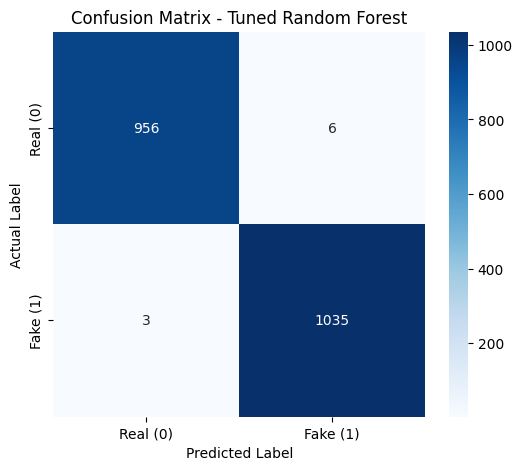

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ১. সেরা মডেল (Random Forest) এর কনফিউশন ম্যাট্রিক্স তৈরি করা
cm = confusion_matrix(y_test, rf_pred)

# ২. সুন্দর একটি হিটম্যাপ প্লট করা
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])

plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()